[ 497  418  537  884 1491 2001 2003 1347  822  497  418  537  884 1491
 2001 2003 1347  822  497  418  537  884 1491 2001 2003 1347  822  497
  418  537  884 1491 2001 2003 1347  822]


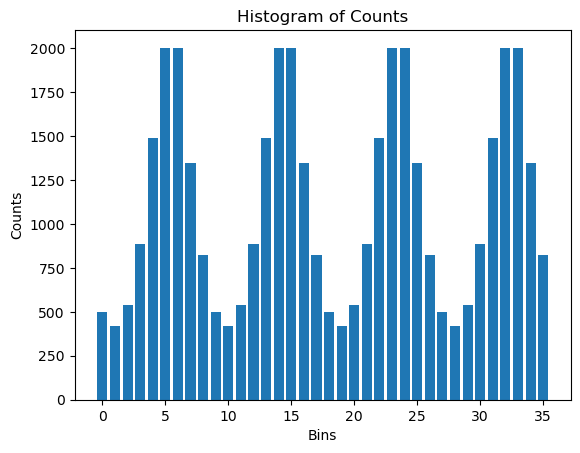

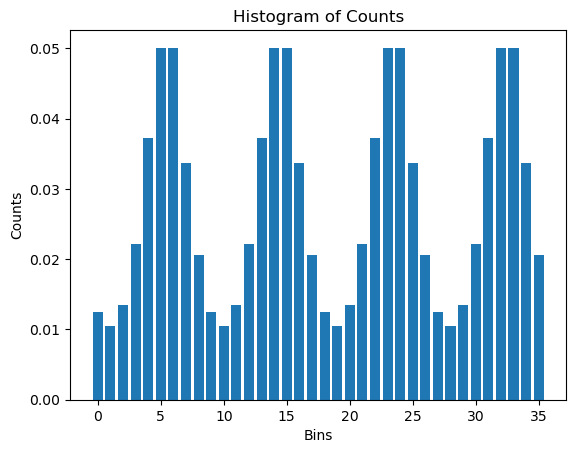

In [34]:
import numpy as np

import matplotlib.pyplot as plt
# Create a random generator
rng = np.random.default_rng()

# Parameters for the von Mises distribution
n_bins = 9
mu = rng.integers(0, n_bins)  # Mode of the distribution (random integer between 0 and 18)
kappa = 0.8  # Dispersion of the distribution
n_samples = 10000  # Number of samples to generate

# Generate samples from the von Mises distribution
samples = rng.vonmises(mu, kappa, n_samples)

# Define the bins over the interval [-pi, pi]
bins = np.linspace(-np.pi, np.pi, n_bins + 1)

# Compute the histogram
counts, bin_edges = np.histogram(samples, bins=bins)
counts = np.concatenate([counts, counts,counts,counts])

# The `counts` array contains the number of samples in each bin
print(counts)

# visualize the counts array as a histogram
plt.bar(range(len(counts)), counts)
plt.xlabel('Bins')
plt.ylabel('Counts')
plt.title('Histogram of Counts')
plt.show()

counts = counts / np.sum(counts)  # Normalize the counts to get a probability distribution

plt.bar(range(len(counts)), counts)
plt.xlabel('Bins')
plt.ylabel('Counts')
plt.title('Histogram of Counts')
plt.show()

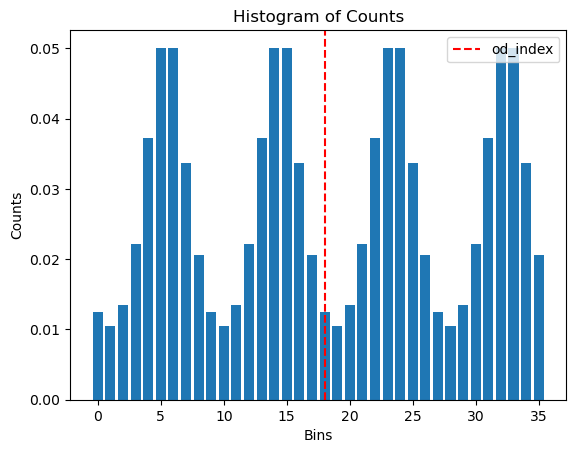

Half length of distribution: 18


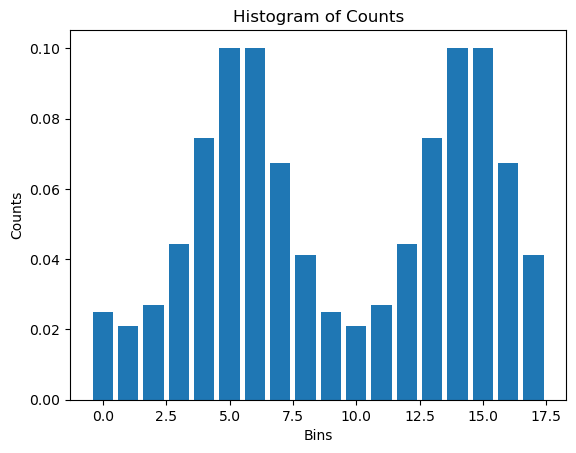

In [ ]:
def to_orientation_dist(dist):
    """Transforms a distribution to a circular distribution."""
    half = len(dist) // 2
    print("Half length of distribution:", half)
    a = dist[half:]
    b = dist[:half]
    orientation_dist = np.empty(half, dtype=float)
    for i in range(0, half):
        orientation_dist[i] = a[i] + b[i]
    return orientation_dist


od_index = len(counts) // 2
plt.bar(range(len(counts)), counts)
plt.xlabel('Bins')
plt.ylabel('Counts')
plt.title('Histogram of Counts')
plt.axvline(od_index, color='red', linestyle='--', label='half index')
plt.legend()
plt.show()

orientation_dist = to_orientation_dist(counts)

plt.bar(range(len(orientation_dist)), orientation_dist)
plt.xlabel('Bins')
plt.ylabel('Counts')
plt.title('Histogram of Counts')
plt.show()



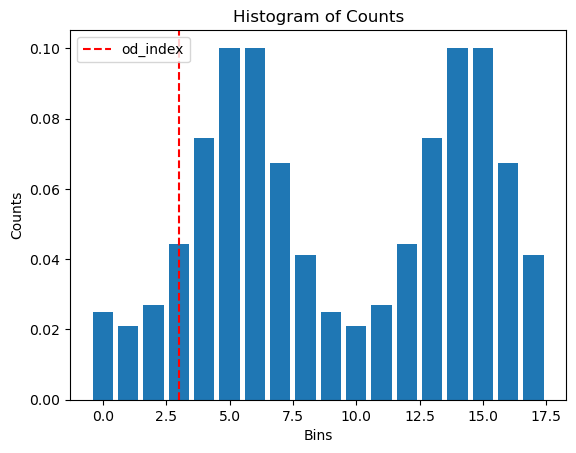

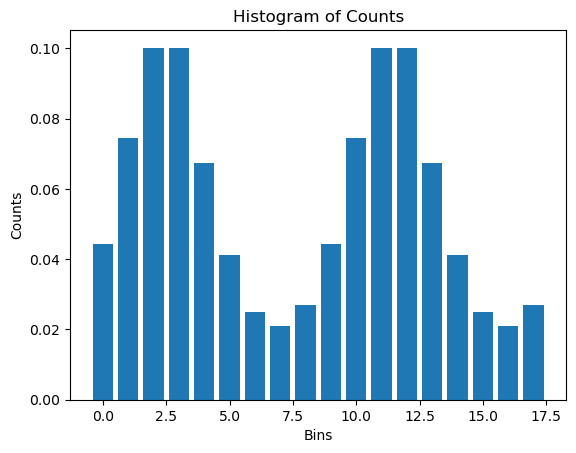

In [36]:

def center_orientations_to_OD(orientation_dist, OD_index):
    """Roll the distribution so that the specified index is at the center."""
    center = len(orientation_dist) // 2
    shift = center - OD_index
    dist = np.roll(orientation_dist, shift)
    return dist

od_index = 3  # Example index to center the distribution around
plt.bar(range(len(orientation_dist)), orientation_dist)
plt.xlabel('Bins')
plt.ylabel('Counts')
plt.title('Histogram of Counts')
plt.axvline(od_index, color='red', linestyle='--', label='od_index')
plt.legend()
plt.show()

orientation_dist_centered = center_orientations_to_OD(orientation_dist, od_index)

plt.bar(range(len(orientation_dist)), orientation_dist_centered)
plt.xlabel('Bins')
plt.ylabel('Counts')
plt.title('Histogram of Counts')
plt.show()

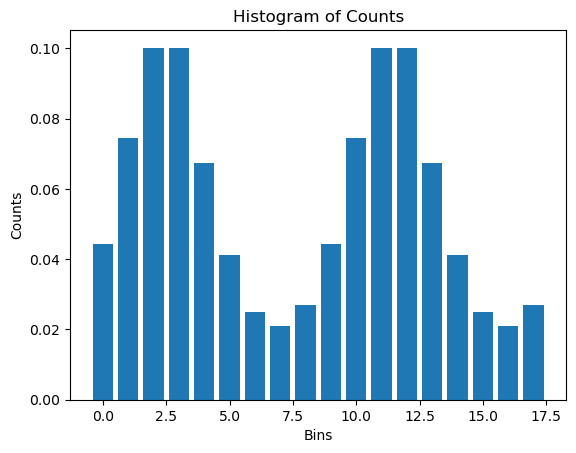

max steps: 9
max orientation frequency: 0.10015
Rotation steps: [-9 -8 -7 -6 -5 -4 -3 -2 -1  0  1  2  3  4  5  6  7  8]


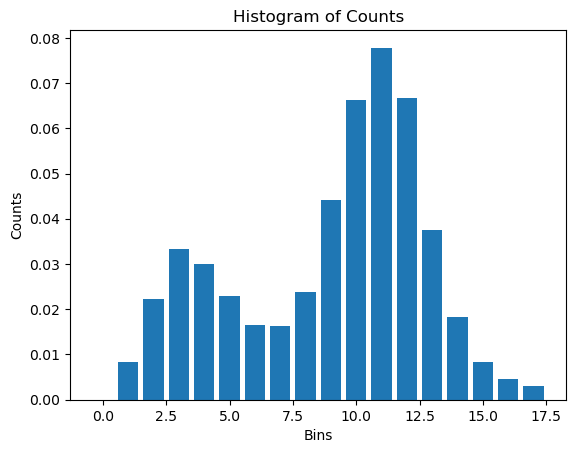

In [37]:

def to_rotation_weighted_dist(orientation_dist):
    max_orientation_frequency = np.max(orientation_dist)
    rotation_steps = np.arange(-len(orientation_dist) // 2, len(orientation_dist) // 2)
    max_steps = np.max(np.abs(rotation_steps))
    print("max steps:", max_steps)
    print("max orientation frequency:", max_orientation_frequency)
    weighted_orientation_dist = np.zeros_like(orientation_dist, dtype=float)
    print("Rotation steps:", rotation_steps)
    for i, frequency in enumerate(orientation_dist):
        steps = np.abs(rotation_steps[i])
        #penalty =  max_orientation_frequency * (steps / max_steps)
        penalty = (1 - (steps / max_steps))   
        #print(f"Index {i}: Frequency {frequency}, Steps {steps}, Penalty {penalty}")
        weighted_frequency = frequency * (1 - (steps / max_steps))
        weighted_orientation_dist[i] = weighted_frequency
    return weighted_orientation_dist

plt.bar(range(len(orientation_dist)), orientation_dist_centered)
plt.xlabel('Bins')
plt.ylabel('Counts')
plt.title('Histogram of Counts')
plt.show()

orientation_dist_weighted = to_rotation_weighted_dist(orientation_dist_centered)

plt.bar(range(18), orientation_dist_weighted)
plt.xlabel('Bins')
plt.ylabel('Counts')
plt.title('Histogram of Counts')
plt.show()
